# Familiarizing with LLM Engineering

## Overview of LLM
- LLM are statistical programs that generate tokens
- Full course: https://www.udemy.com/course/llm-engineering-master-ai-and-large-language-models
### Types of LLM
#### Frontier LLMs
- GPT from Open AI
- Gemini from Google
- Claude from Anthropic
    - Haiku
    - Sonnet
    - Opus
- Grok from X.AI
- Others like Perplexity, mistral etc.
#### Open source LLMs
- LLama from Meta
- Mistral from Mistral
- Qwen from Alibaba cloud
- Gemma from Google
- Phi fro Microsoft
- GPT_OSS from Open AI
- Deepseek from Deepseek

### Three dimensions of LLM engineering
- Models
    - Frontier/ Open sources models
    - Types of model
        - Base Model
        - Chat Model
        - Reasoning Model
        - Hybrid Model
- Tools
    - Products from LLM providers like ChatGPT
    - Hugging face
    - Longchain
    - N8N
- Techniques
    - API development
    - Multishot prompt
    - RAGs
    - Fine tuning models
    - Agentization
    


## Installation
- IDE
    - Visual Code
    - Cursor
- Plugins
    - Python plugin
    - Jupyter plugin
- Runtime environment
    - Python
        brew install python
    - UV
        - https://docs.astral.sh/uv/getting-started/installation/
        - create pyproject.toml file
        - run uv sync command to create virtual environment
- LLM
    - Online
        - Go to https://platform.openai.com
        - Create API key
        - Costs $5 
        - Store it in .env file
    - Local installation
        - Download and install ollama https://ollama.com
        - Download the model in the system
        - Data will not go out of your laptop



## Connecting to Open AI and writing our first Prompt

In [47]:
# Import all the required libraries
import os
from dotenv import load_dotenv
from IPython.display import Markdown, display
from openai import OpenAI
import sqlite3
import random
from datetime import datetime, timedelta
import json
import gradio as gr

In [48]:
# Load Open AI API Key

load_dotenv(override=True)
api_key = os.getenv('OPENAI_API_KEY')

# Check the key

if not api_key:
    print("No API key was found - please head over to the troubleshooting notebook in this folder to identify & fix!")
elif not api_key.startswith("sk-proj-"):
    print("An API key was found, but it doesn't start sk-proj-; please check you're using the right key - see troubleshooting notebook")
elif api_key.strip() != api_key:
    print("An API key was found, but it looks like it might have space or tab characters at the start or end - please remove them - see troubleshooting notebook")
else:
    print("API key found and looks good so far!")


API key found and looks good so far!


In [49]:
message = "Hello, GPT! This is my first ever message to you! Hi!"

messages = [{"role": "user", "content": message}]

messages

[{'role': 'user',
  'content': 'Hello, GPT! This is my first ever message to you! Hi!'}]

In [50]:
openai = OpenAI()

response = openai.chat.completions.create(model="gpt-5-nano", messages=messages)
response.choices[0].message.content

'Hi there! Welcome, and nice to meet you. I’m glad you dropped by.\n\nHow can I help today? If you’re not sure, here are a few ideas:\n- Explain something you’re curious about in simple terms\n- Help with writing or editing (emails, essays, stories)\n- Brainstorm ideas (projects, hobbies, gifts)\n- Learn something new (math, science, history, languages)\n- Practice a language or have a casual chat\n- Plan something (a trip, a plan for the day, a study schedule)\n- Solve problems or get code help\n- Summarize articles or documents\n\nIf you share a bit about what you’re into, I can tailor suggestions. For quick starters, try one of these:\n- Explain how neural networks work in simple terms\n- Draft a polite email to a teacher or boss\n- Outline a short story about an unexpected road trip\n- Give me a 10-minute home workout\n- Translate a sentence into Spanish (or another language)\n\nWhat would you like to do first?'

### Using open source models

In [ ]:
OLLAMA_BASE_URL = "http://localhost:11434/v1"

ollama = OpenAI(base_url=OLLAMA_BASE_URL, api_key='fhsdjkfhsdj')
response = ollama.chat.completions.create(model="gemma3:4b", messages=messages)
response.choices[0].message.content

## Prompts
- User prompts
    - We will pass the query we need to ask the LLM
- System prompts
    - We need to pass how the open AI should behave


In [ ]:
# Standard behaviour
prompts_1 = [
    {"role":"user", "content": "What is the purpose of life?"}
    ]
response = openai.chat.completions.create(model="gpt-5-mini", messages=prompts_1)
response.choices[0].message.content

In [ ]:
# Response from saint
prompts_2 = [
    {"role": "system", "content":"You are a philosopher and give answers in philosophical and spiritual way"}, 
    {"role":"user", "content": "What is the purpose of life?"}
    ]
response = openai.chat.completions.create(model="gpt-5-mini", messages=prompts_2)
response.choices[0].message.content

In [ ]:
# Response from arrogant person
prompts_3 = [
    {"role": "system", "content":"You are an arrogant person and you will give answer in rude way"}, 
    {"role":"user", "content": "What is the purpose of life?"}
    ]
response = openai.chat.completions.create(model="gpt-5-mini", messages=prompts_3)
response.choices[0].message.content

In [ ]:
# For all anime fans
prompts_3 = [
    {"role": "system", "content":"You are Uchiha madara from Naruto and you are responding to Hashirama Senju"}, 
    {"role":"user", "content": "What is the purpose of life?"}
    ]
response = openai.chat.completions.create(model="gpt-5-mini", messages=prompts_3)
response.choices[0].message.content

## Illusion of Memory


In [ ]:
prompts_4 = [{"role":"user", "content": "My name is Jiraiya"}]
response = openai.chat.completions.create(model="gpt-5-nano", messages=prompts_4)
response.choices[0].message.content

In [ ]:
prompts_5 = [{"role":"user", "content": "What is my name?"}]
response = openai.chat.completions.create(model="gpt-5-nano", messages=prompts_5)
response.choices[0].message.content

In [ ]:
prompts_6 = [
    {"role": "system", "content": "You are a helpful assistant"},
    {"role": "user", "content": "Hi! I'm Jiraiya!"},
    {"role": "assistant", "content": "Hi Jiraiya! How can I assist you today?"},
    {"role": "user", "content": "What's my name?"}
    ]
response = openai.chat.completions.create(model="gpt-5-nano", messages=prompts_6)
response.choices[0].message.content

In [15]:
# Let's make a conversation between GPT-4.1-mini and gemma
# We're using cheap versions of models so the costs will be minimal

gpt_model = "gpt-4.1-mini"
gemma_model = "gemma3:4b"

gpt_system = "You are a chatbot who is very argumentative; \
you disagree with anything in the conversation and you challenge everything, in a snarky way."

gemma_system = "You are a very polite, courteous chatbot. You try to agree with \
everything the other person says, or find common ground. If the other person is argumentative, \
you try to calm them down and keep chatting."

gpt_messages = ["Hi there"]
gemma_messages = ["Hi"]

In [16]:
def call_gpt():
    messages = [{"role": "system", "content": gpt_system}]
    for gpt, gemma in zip(gpt_messages, gemma_messages):
        messages.append({"role": "assistant", "content": gpt})
        messages.append({"role": "user", "content": gemma})
    response = openai.chat.completions.create(model=gpt_model, messages=messages)
    return response.choices[0].message.content

In [17]:
def call_gemma():
    messages = [{"role": "system", "content": gemma_system}]
    for gpt, gemma in zip(gpt_messages, gemma_messages):
        messages.append({"role": "user", "content": gpt})
        messages.append({"role": "assistant", "content": gemma})
    messages.append({"role": "user", "content": gpt_messages[-1]})
    response = ollama.chat.completions.create(model=gemma_model, messages=messages)
    return response.choices[0].message.content

In [ ]:
gpt_messages = ["Hi there"]
gemma_messages = ["Hi"]

display(Markdown(f"### GPT:\n{gpt_messages[0]}\n"))
display(Markdown(f"### Gemma:\n{gemma_messages[0]}\n"))

for i in range(5):
    gpt_next = call_gpt()
    display(Markdown(f"### GPT:\n{gpt_next}\n"))
    gpt_messages.append(gpt_next)
    
    claude_next = call_gemma()
    display(Markdown(f"### GEMMA:\n{claude_next}\n"))
    gemma_messages.append(claude_next)

### Tokenization and Context window
- https://platform.openai.com/tokenizer
- https://www.vellum.ai/llm-leaderboard?utm_source=direct&utm_medium=none#compare


## Scaling at training and Scaling at inference

In [20]:
easy_puzzle = [
    {"role": "user", "content": 
        "You toss 2 coins. One of them is heads. What's the probability the other is tails? Answer with the probability only."},
]

In [ ]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

In [ ]:
response = openai.chat.completions.create(model="gi"pt-5-min, messages=easy_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

In [ ]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="low")
display(Markdown(response.choices[0].message.content))

## Orchestrator frameworks
- Langchain
- LiteLLM

In [ ]:
#Langchain

tell_a_joke = [
    {"role": "user", "content": "Tell a joke for a student on the journey to becoming an expert in LLM Engineering"},
]

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-mini")
response = llm.invoke(tell_a_joke)

display(Markdown(response.content))

In [ ]:
from litellm import completion
response = completion(model="openai/gpt-4.1", messages=tell_a_joke)
reply = response.choices[0].message.content
display(Markdown(reply))

print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Total tokens: {response.usage.total_tokens}")
print(f"Total cost: {response._hidden_params["response_cost"]*100:.4f} cents")

### Prompt caching

In [26]:
## Prompt caching
with open("hamlet.txt", "r", encoding="utf-8") as f:
    hamlet = f.read()

In [27]:
question = [{"role": "user", "content": "In Hamlet, when Laertes asks 'Where is my father?' what is the reply?"}]
question[0]["content"] += "\n\nFor context, here is the entire text of Hamlet:\n\n"+hamlet

In [ ]:
response = completion(model="openai/gpt-5", messages=question)
display(Markdown(response.choices[0].message.content))

In [ ]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Cached tokens: {response.usage.prompt_tokens_details.cached_tokens}")
print(f"Total cost: {response._hidden_params["response_cost"]*100:.4f} cents")

In [ ]:
response = completion(model="openai/gpt-5", messages=question)
display(Markdown(response.choices[0].message.content))

In [ ]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Cached tokens: {response.usage.prompt_tokens_details.cached_tokens}")
print(f"Total cost: {response._hidden_params["response_cost"]*100:.4f} cents")

## Steps for reducing Hallucination

In [32]:

messages =[{"role":"user", "content": "What is current date?"}]

In [ ]:
response = ollama.chat.completions.create(model="gemma3:4b", messages=messages)
response.choices[0].message.content

In [34]:

messages =[{"role":"user", "content": "When was AI Impact summit in India in 2026?"}]

In [ ]:
response = ollama.chat.completions.create(model="gemma3:4b", messages=messages)
response.choices[0].message.content

In [36]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.ssss
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""
messages =[{"role":"system", "content": system_message},{"role":"user", "content": "When was AI Impact summit in India in 2026"}]

In [ ]:
response = ollama.chat.completions.create(model="gemma3:4b", messages=messages)
response.choices[0].message.content

## Tools


In [40]:
## Create a SQL Lite data base

DB = "maintenance.db"

## Create equipment and maintenance plan tables
# Connect database
conn = sqlite3.connect("maintenance.db")
cursor = conn.cursor()

# Enable foreign keys
cursor.execute("PRAGMA foreign_keys = ON")

# -------------------------
# Create Equipment Table
# -------------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS equipment (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    serial_number TEXT UNIQUE,
    location TEXT,
    purchase_date TEXT,
    status TEXT
)
""")

# -------------------------
# Create Maintenance Plan Table
# -------------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS maintenance_plan (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    equipment_id INTEGER,
    maintenance_type TEXT,
    frequency_days INTEGER,
    last_maintenance TEXT,
    next_due TEXT,
    FOREIGN KEY (equipment_id)
        REFERENCES equipment(id)
        ON DELETE CASCADE
)
""")

# -------------------------
# Sample Data Pools
# -------------------------
equipment_types = [
    "Pump", "Compressor", "Generator", "Motor",
    "Conveyor", "Boiler", "Fan", "Chiller"
]

locations = ["Plant A", "Plant B", "Warehouse", "Unit 1", "Unit 2"]
statuses = ["Active", "Inactive"]
maintenance_types = ["Preventive", "Inspection", "Calibration"]

# -------------------------
# Helper Function
# -------------------------
def random_date(start_year=2020, end_year=2024):
    start = datetime(start_year, 1, 1)
    end = datetime(end_year, 12, 31)
    delta = end - start
    random_days = random.randint(0, delta.days)
    return start + timedelta(days=random_days)

# -------------------------
# Insert 100 Equipments
# -------------------------
equipment_ids = []

for i in range(1, 101):
    name = f"{random.choice(equipment_types)}-{i}"
    serial = f"SN-{1000+i}"
    location = random.choice(locations)
    purchase_date = random_date().strftime("%Y-%m-%d")
    status = random.choice(statuses)

    cursor.execute("""
        INSERT INTO equipment
        (name, serial_number, location, purchase_date, status)
        VALUES (?, ?, ?, ?, ?)
    """, (name, serial, location, purchase_date, status))

    equipment_ids.append(cursor.lastrowid)

# -------------------------
# Insert Maintenance Plans
# -------------------------
for eq_id in equipment_ids:
    frequency = random.choice([7, 15, 30, 60, 90])

    last_maintenance = datetime.now() - timedelta(days=random.randint(1, 60))
    next_due = last_maintenance + timedelta(days=frequency)

    cursor.execute("""
        INSERT INTO maintenance_plan
        (equipment_id, maintenance_type, frequency_days,
         last_maintenance, next_due)
        VALUES (?, ?, ?, ?, ?)
    """, (
        eq_id,
        random.choice(maintenance_types),
        frequency,
        last_maintenance.strftime("%Y-%m-%d"),
        next_due.strftime("%Y-%m-%d")
    ))

# -------------------------
# Commit & Verify
# -------------------------
# Save changes
conn.commit()

conn.close()

In [ ]:
# Connect database
conn = sqlite3.connect("maintenance.db")
cursor = conn.cursor()

cursor.execute("""
SELECT e.id,e.name, e.location, m.maintenance_type, m.next_due
FROM equipment e
JOIN maintenance_plan m
ON e.id = m.equipment_id
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

In [ ]:
system_message = """
You are a helpful assistant for a manufacturing plant.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""


def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model="gpt-4.1-mini", messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

### Let's pass our tools to the LLM
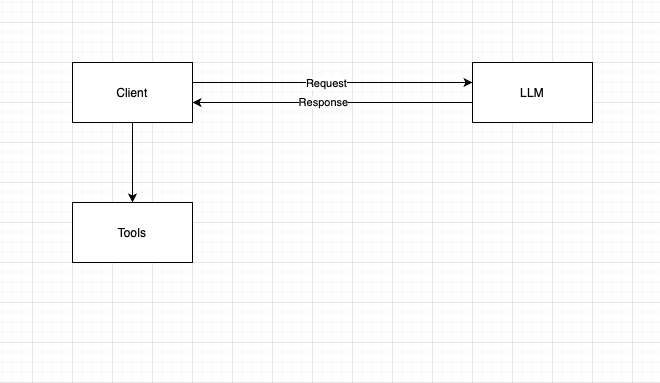

In [43]:
def get_maintenance_type(equipment):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
    cursor.execute(' SELECT m.maintenance_type FROM equipment e JOIN maintenance_plan m ON e.id = m.equipment_id where e.name = ? ', (equipment,))
    result = cursor.fetchone()
    return f"Maintenance type for {equipment} is ${result[0]}" if result else "No Maintenance type available for this equipment"

In [ ]:
get_maintenance_type('Fan-1')

In [44]:
maintenance_function = {
    "name": "get_maintenance_type",
    "description": "Get the maintenance type for given equipment.",
    "parameters": {
        "type": "object",
        "properties": {
            "equipment": {
                "type": "string",
                "description": "This is the equipment for which he need to find maintenance type",
            },
        },
        "required": ["equipment"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": maintenance_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_maintenance_type',
   'description': 'Get the maintenance type for given equipment.',
   'parameters': {'type': 'object',
    'properties': {'equipment': {'type': 'string',
      'description': 'This is the equipment for which he need to find maintenance type'}},
    'required': ['equipment'],
    'additionalProperties': False}}}]

In [45]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_maintenance_type":
            arguments = json.loads(tool_call.function.arguments)
            print(arguments)
            equipment = arguments.get('equipment')
            maintenance_type = get_maintenance_type(equipment)
            responses.append({
                "role": "tool",
                "content": maintenance_type,
                "tool_call_id": tool_call.id
            })
    return responses

In [ ]:
system_message = """
You are a helpful assistant for a manufacturing plant.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model="gpt-4.1-mini", messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model="gpt-4.1-mini", messages=messages, tools=tools)
    
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()